In [3]:
import pysmu
s=pysmu.Session()
sig=pysmu.Signal()

In [2]:
s._close()

In [4]:
dev=s.devices[0]
print(dev)

serial 2031205052543339323430333230303 : fw 2.17 : hw F


In [5]:
dev.channels["A"].mode=pysmu.Mode.SVMI
dev.channels["B"].mode=pysmu.Mode.HI_Z

[5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053, 4.877641201019287, 5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053, 4.877641201019287, 5.0, 4.877641201019287, 4.522542476654053, 3.9694631099700928, 3.2725424766540527, 2.5, 1.7274575233459473, 1.0305368900299072, 0.47745752334594727, 0.12235870957374573, 0.0, 0.12235870957374573, 0.47745752334594727, 1.0305368900299072, 1.7274575233459473, 2.5, 3.2725424766540527, 3.9694631099700928, 4.522542476654053

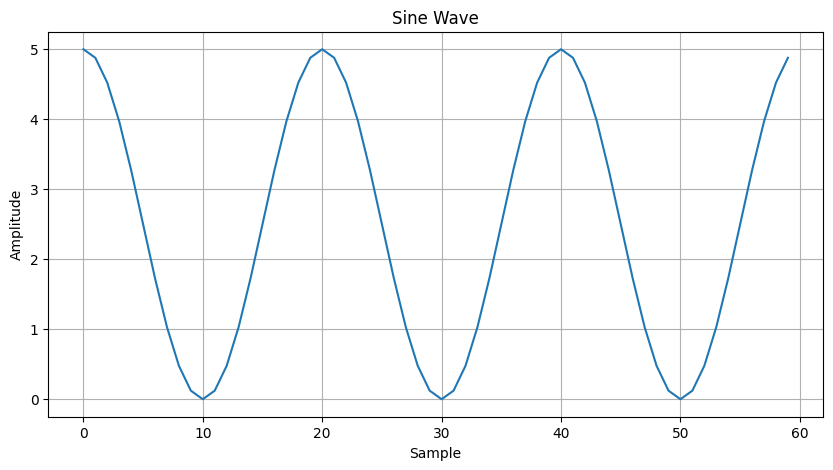

In [6]:
sig=pysmu.Signal()
p=20
sine_wave = sig.sine(samples=3*p, midpoint=0, peak=5, period=p, phase=0)
print(sine_wave)
import numpy as np
x=sine_wave
signal = x - np.mean(x)
N = len(signal)

spectrum = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(N, d=1)  # cycles/sample

peak_idx = np.argmax(np.abs(spectrum[1:])) + 1
peak_freq = freqs[peak_idx]

print("Frequency =", peak_freq, "cycles/sample")
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(sine_wave)
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Sine Wave')
plt.grid(True)
plt.show()

In [7]:
dev.channels["A"].write(sine_wave,-1)
s.start(10*p+100)

In [8]:
data = dev.read(100)
data= dev.read(10*p+100)
list1, list2, list3, list4 = [], [], [], []

# Loop through the items without unpacking them immediately
for item in data:
    # Check if the item is actually a tuple 
    if isinstance(item, tuple):
        # Now it is safe to unpack
        (a, b), (c, d) = item
        list1.append(a)
        list2.append(b)
        list3.append(c)
        list4.append(d)
    else:
        # If it hits the '...', it simply ignores it and moves on
        continue

print(list1)
print(list3)
print(len(list1))
print(len(list3))

[4.939373970031738, 4.68641471862793, 4.237298488616943, 3.6123909950256348, 2.8963489532470703, 2.1473803520202637, 1.4179960489273071, 0.7702265381813049, 0.30246245861053467, 0.07548568397760391, 0.058710161596536636, 0.3037108778953552, 0.7376117706298828, 1.3529225587844849, 2.095571279525757, 2.8793394565582275, 3.6116106510162354, 4.245725154876709, 4.6907057762146, 4.918540954589844, 4.939295768737793, 4.68641471862793, 4.237376689910889, 3.612468957901001, 2.8963489532470703, 2.1473803520202637, 1.4179179668426514, 0.7703045606613159, 0.30254048109054565, 0.07540766149759293, 0.058710161596536636, 0.3037889003753662, 0.7376117706298828, 1.3529225587844849, 2.095571279525757, 2.8793394565582275, 3.611532688140869, 4.245803356170654, 4.69086217880249, 4.918619155883789, 4.939295768737793, 4.686492443084717, 4.237298488616943, 3.6123909950256348, 2.896270990371704, 2.1473803520202637, 1.4179179668426514, 0.7703045606613159, 0.30246245861053467, 0.0755637139081955, 0.0586321353912

In [9]:
import time
def measure_gain_phase_at_freqs(s,dev, ps,amp):
    results = []
    for p in ps:
        sine_wave = sig.sine(samples=10*p+100, midpoint=amp[0], peak=amp[1], period=p, phase=0)
        dev.channels["A"].write(sine_wave,-1)
        time.sleep(1/10)# Allow some time for the signal to stabilize
        s.start(10*p+100) 
        time.sleep(1/10)# Allow some time for the measurement to complete
        data = dev.read(100)
        data = dev.read(10*p)
        list1, list3 = [], []
        for item in data:
            if isinstance(item, tuple):
                (a, b), (c, d) = item
                list1.append(a)
                list3.append(c)
        print(f"Measured {len(list1)} samples for period {p}")
        result = (list1, list3)
        results.append(result)
    return results

In [10]:
def gain_phase(inp, out):
    x = np.asarray(inp, dtype=float)
    y = np.asarray(out, dtype=float)

    # Remove DC
    x = x - np.mean(x)
    y = y - np.mean(y)

    N = len(x)

    # FFT
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y)

    # Ignore DC bin
    k = np.argmax(np.abs(X[1:])) + 1

    # Transfer function
    H = Y[k] / X[k]

    mag_linear = np.abs(H)
    mag_db = 20 * np.log10(mag_linear)

    phase_deg = np.angle(H, deg=True)

    freq_cycles_per_sample = k / N

    return {
        "frequency_cycles_per_sample": freq_cycles_per_sample,
        "magnitude_linear": mag_linear,
        "magnitude_db": mag_db,
        "phase_deg": phase_deg
    }

In [38]:
import numpy as np

k = gain_phase(list1, list3)

print(f"Magnitude = {k['magnitude_linear']:.4f}")
print(f"Gain (dB) = {k['magnitude_db']:.4f}")
print(f"Phase = {k['phase_deg']:.4f} degrees")

Magnitude = 1.0096
Gain (dB) = 0.0831
Phase = 8.2240 degrees


In [13]:
ps=range(20,500,10)
measurement_results = measure_gain_phase_at_freqs(s,dev, ps, amp=[0, 5])

Measured 200 samples for period 20
Measured 300 samples for period 30
Measured 400 samples for period 40
Measured 500 samples for period 50
Measured 600 samples for period 60
Measured 700 samples for period 70
Measured 800 samples for period 80
Measured 900 samples for period 90
Measured 1000 samples for period 100
Measured 1100 samples for period 110
Measured 1200 samples for period 120
Measured 1300 samples for period 130
Measured 1400 samples for period 140
Measured 1500 samples for period 150
Measured 1600 samples for period 160
Measured 1700 samples for period 170
Measured 1800 samples for period 180
Measured 1900 samples for period 190
Measured 2000 samples for period 200
Measured 2100 samples for period 210
Measured 2200 samples for period 220
Measured 2300 samples for period 230
Measured 2400 samples for period 240
Measured 2500 samples for period 250
Measured 2600 samples for period 260
Measured 2700 samples for period 270
Measured 2800 samples for period 280
Measured 2900 sam

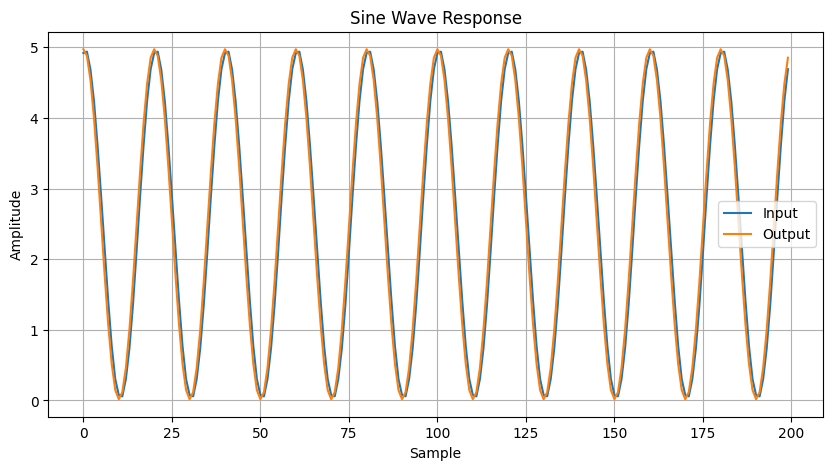

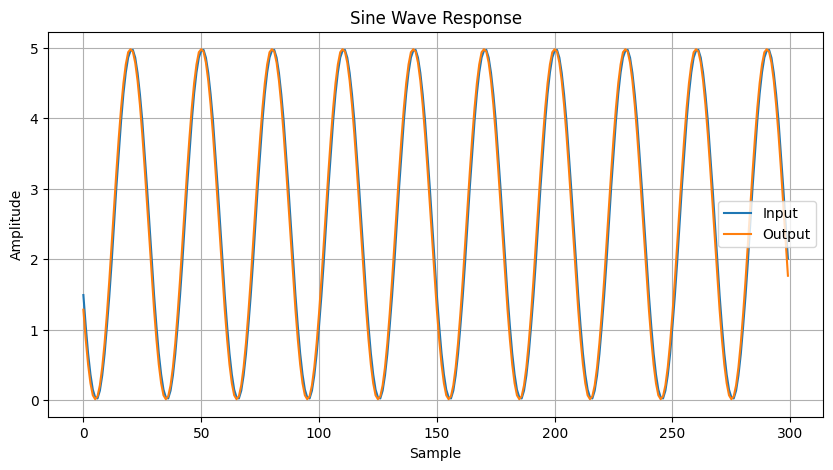

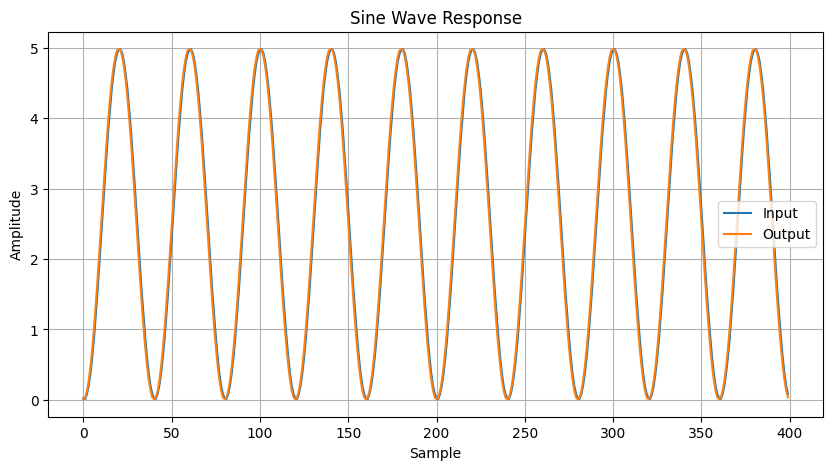

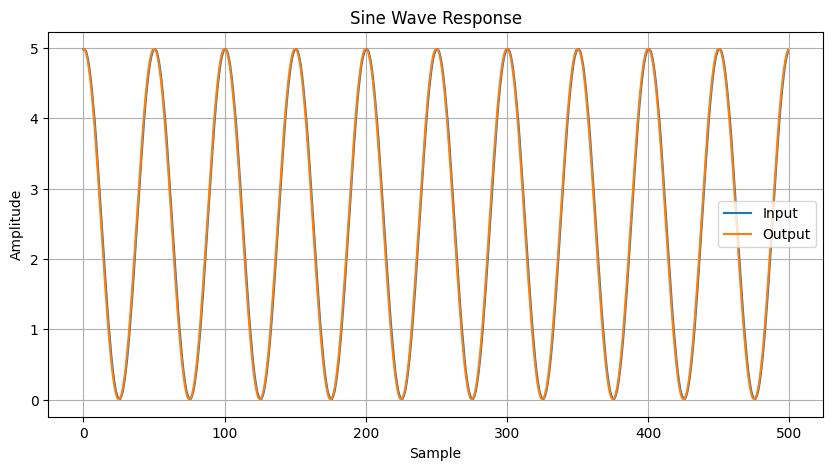

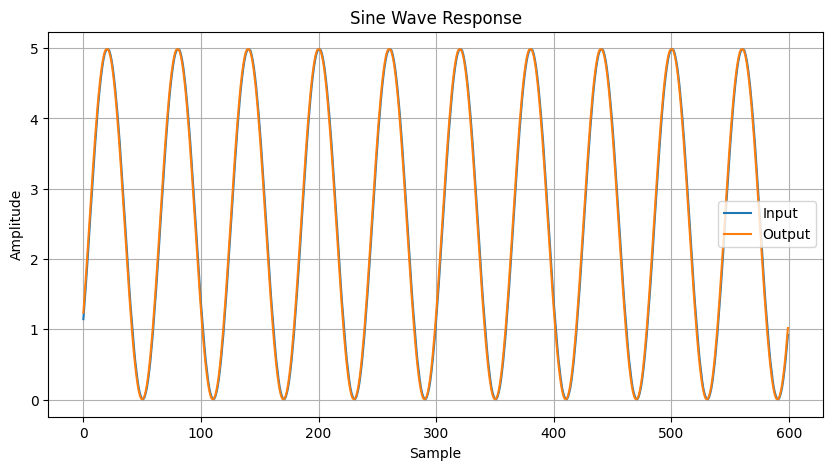

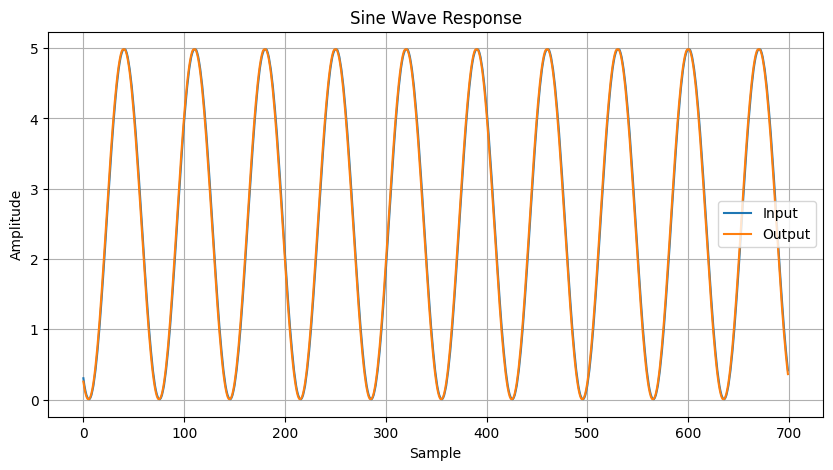

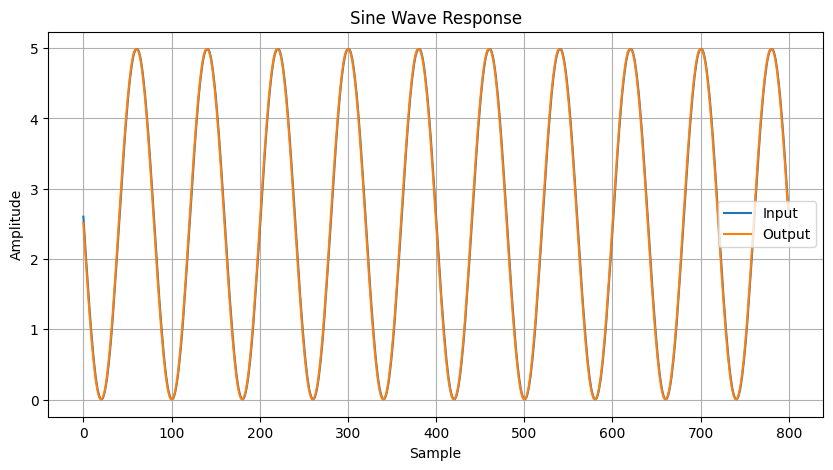

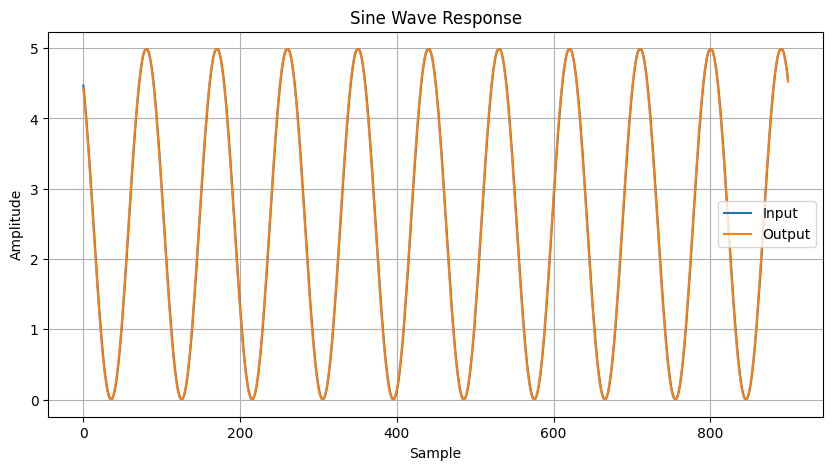

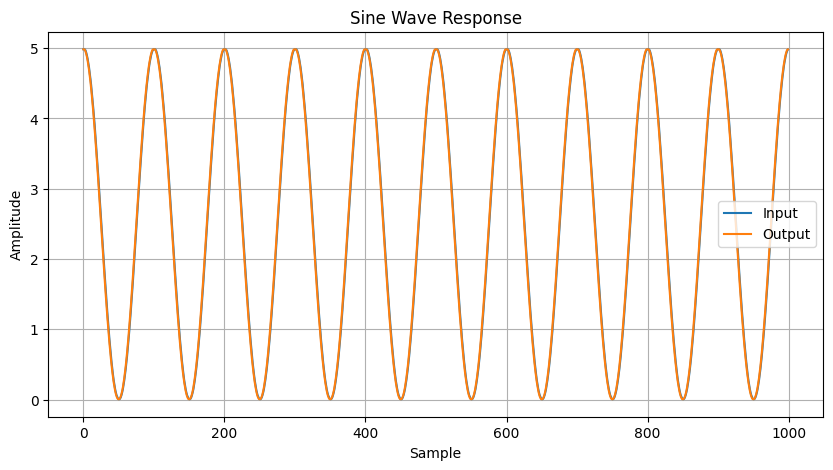

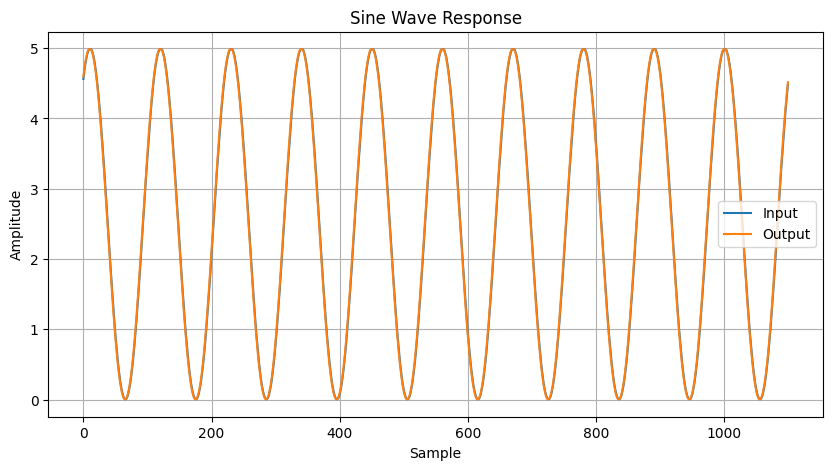

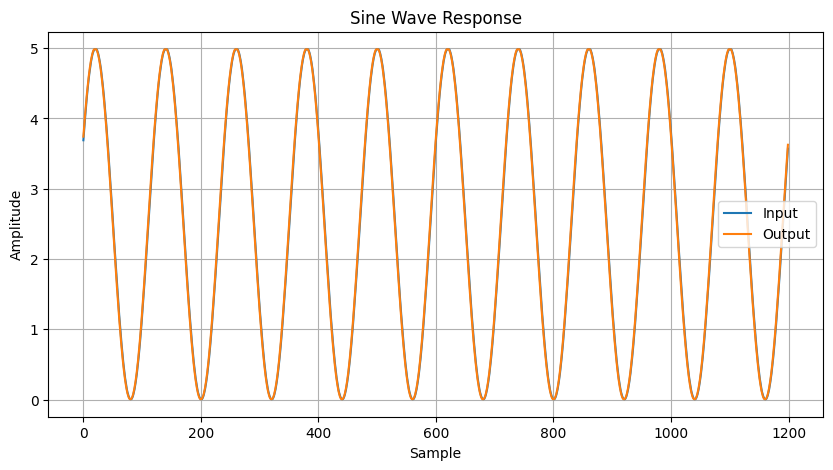

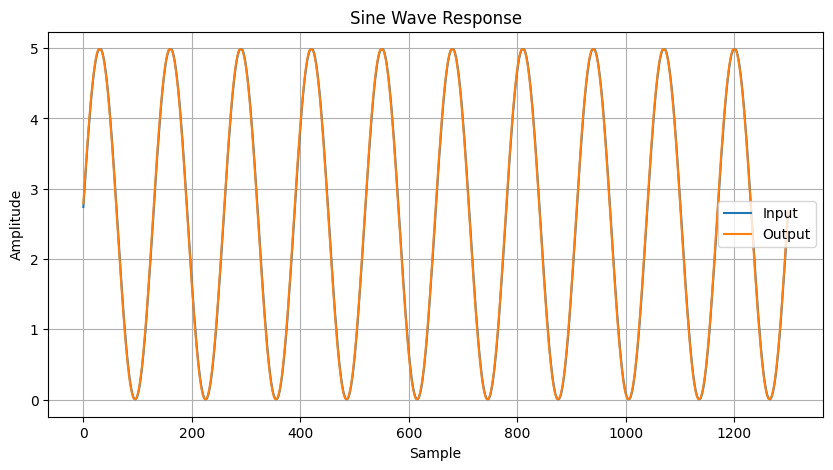

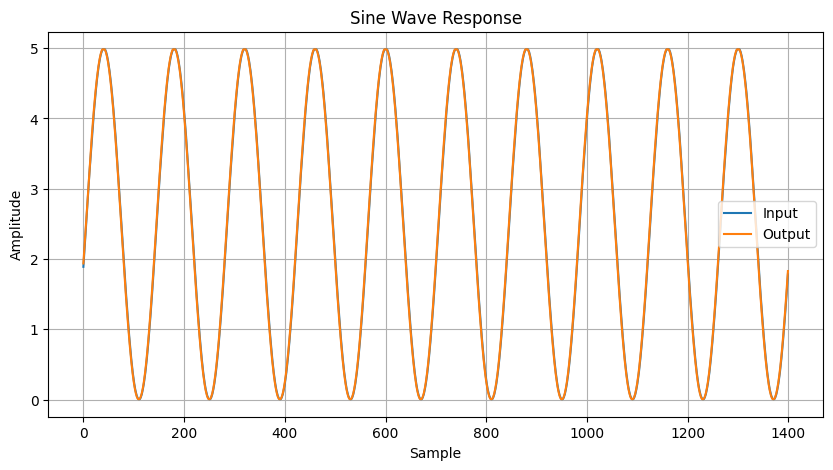

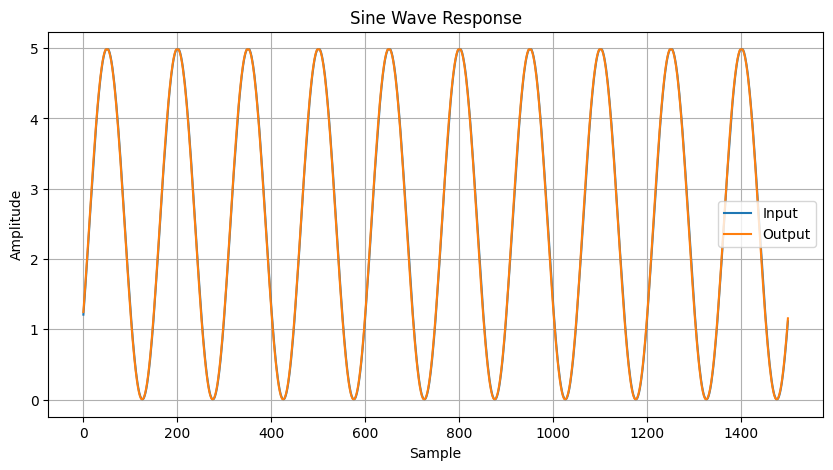

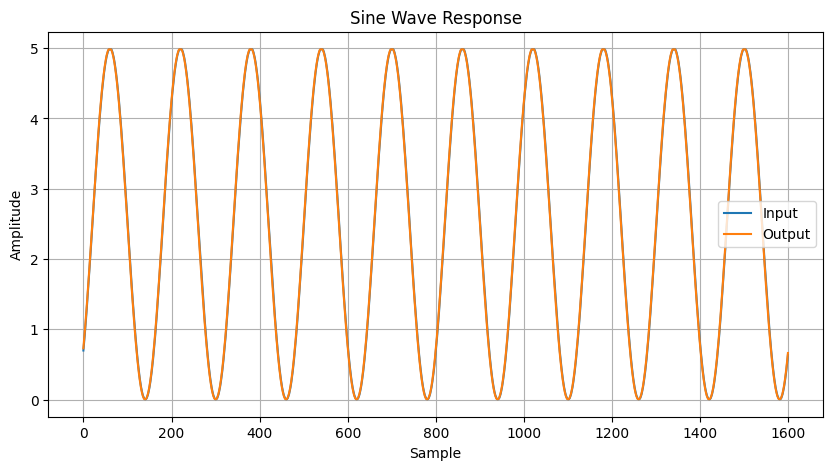

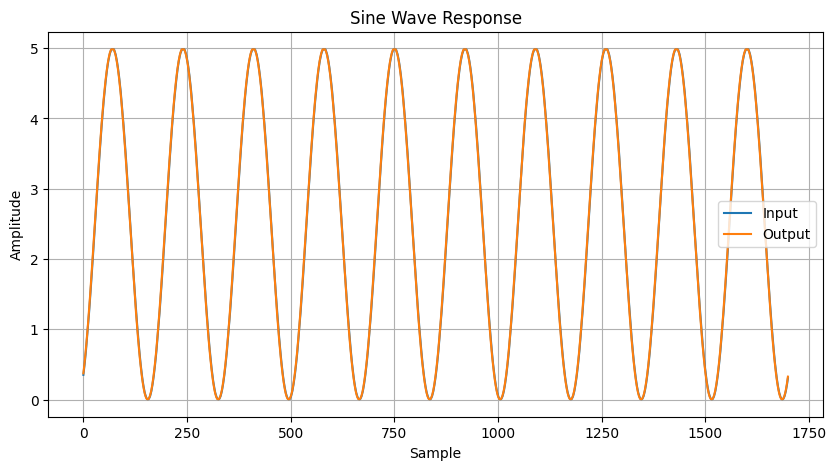

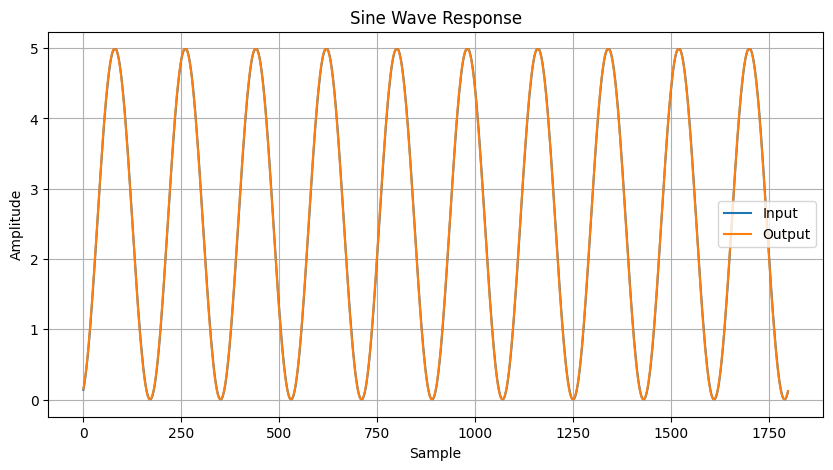

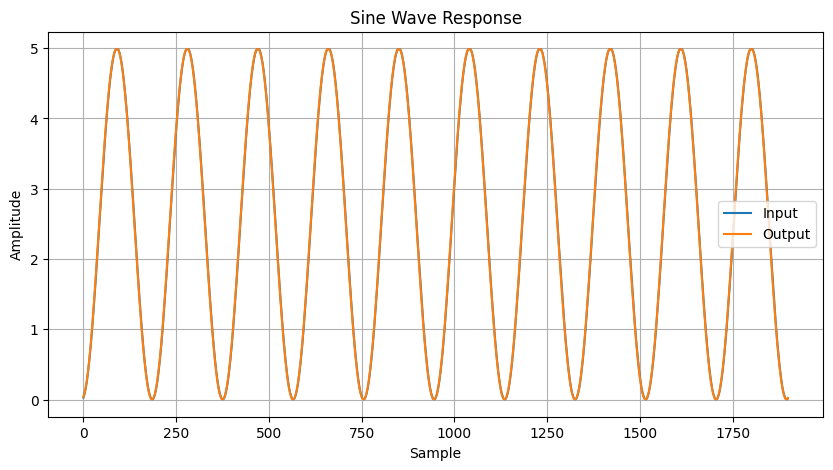

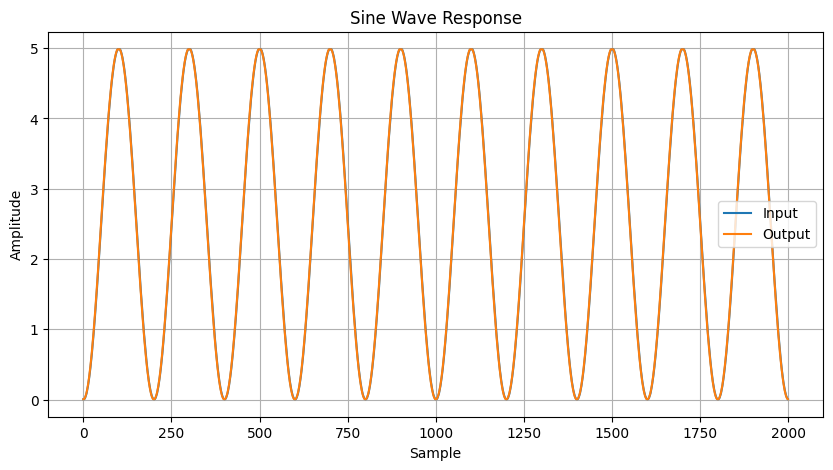

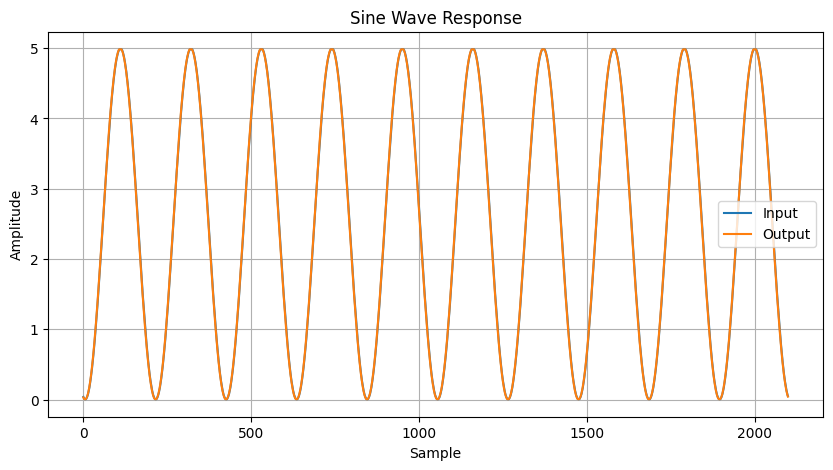

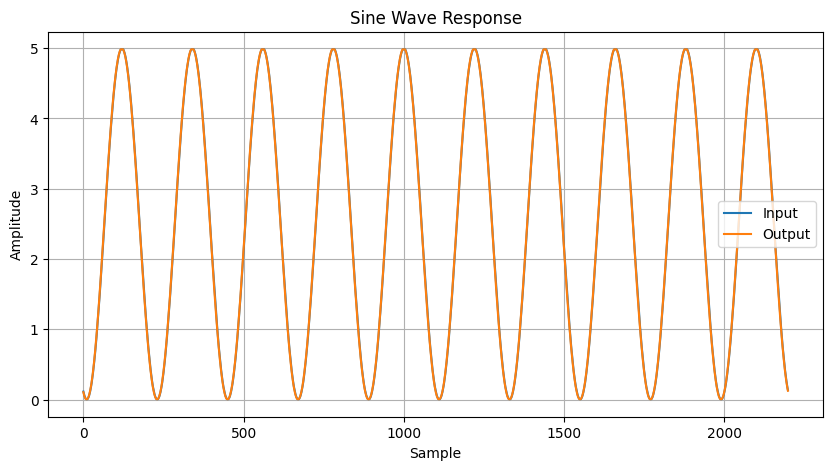

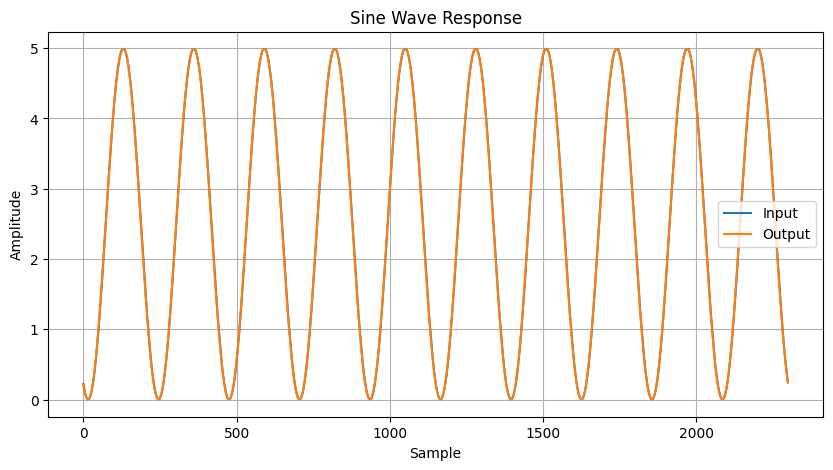

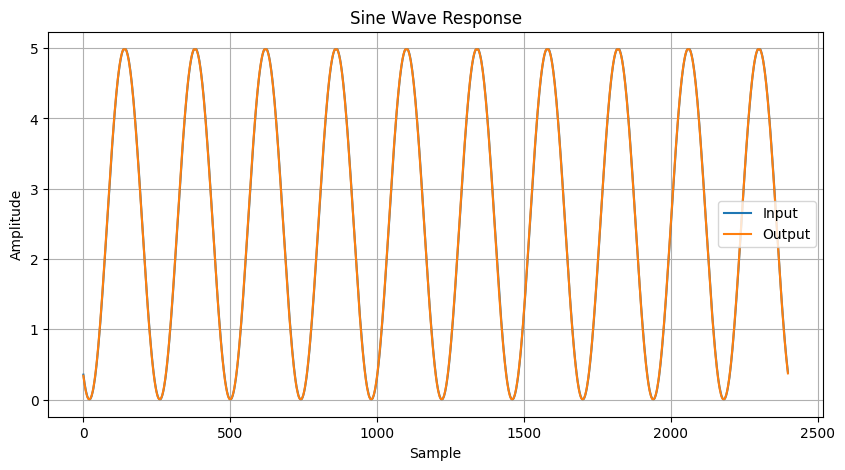

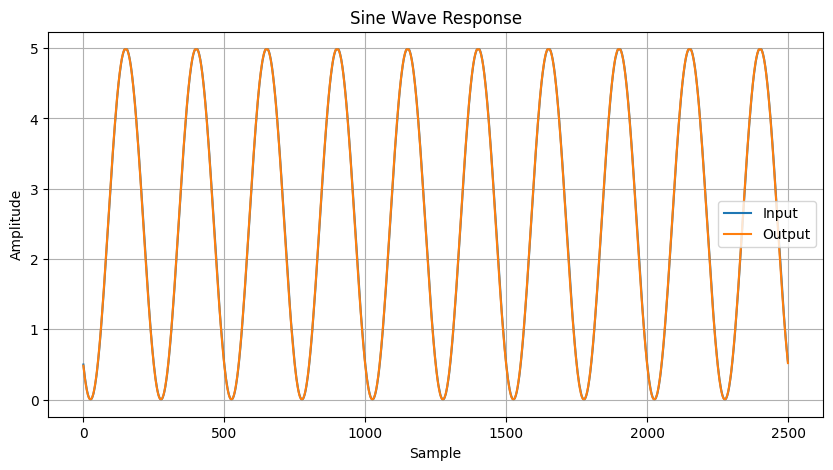

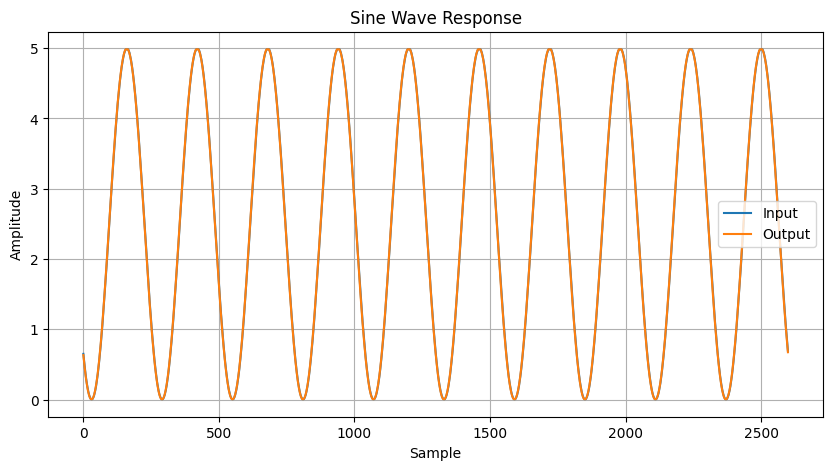

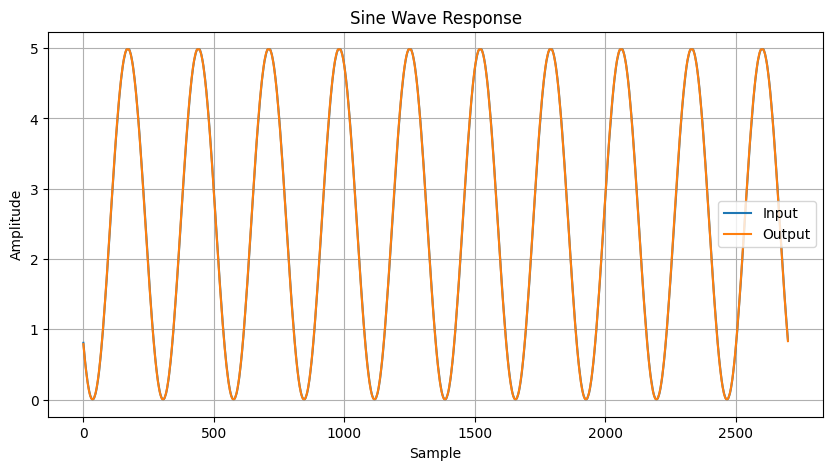

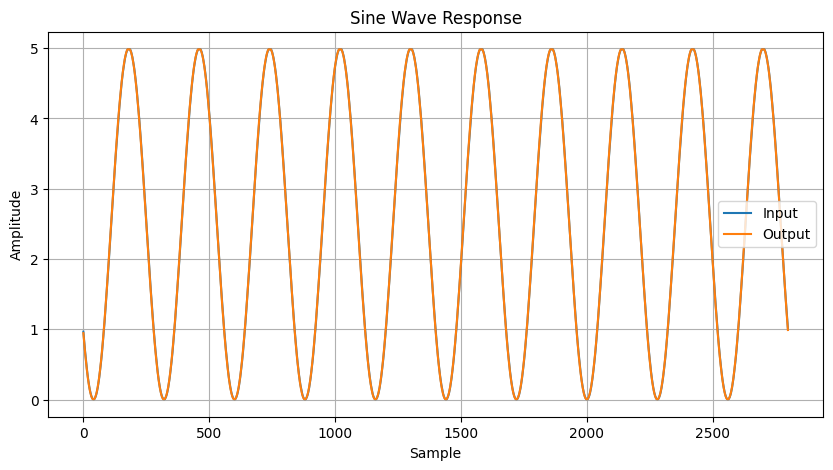

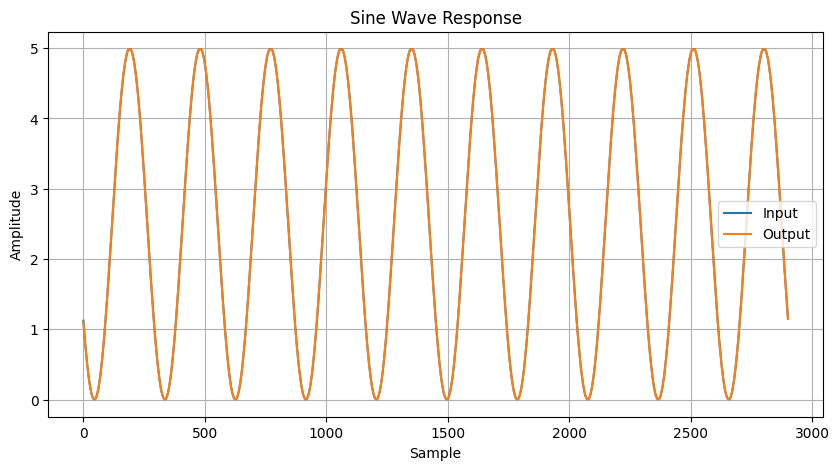

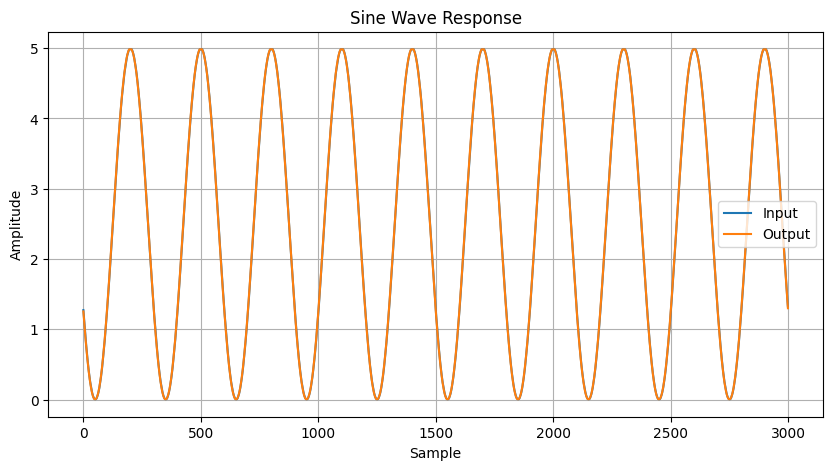

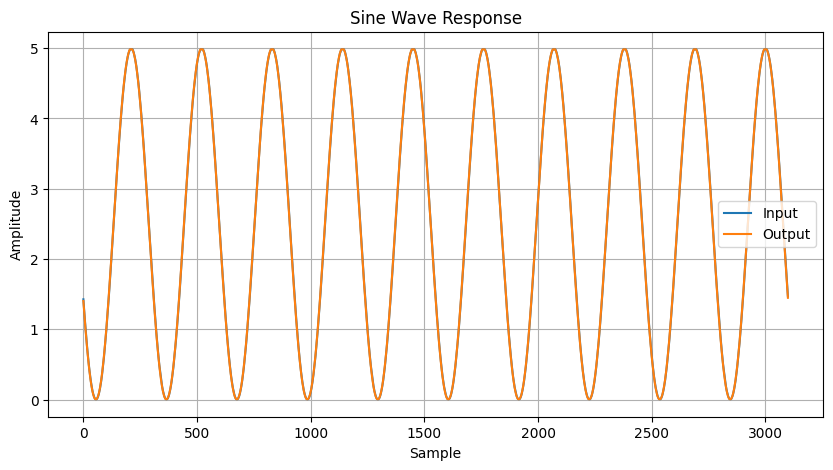

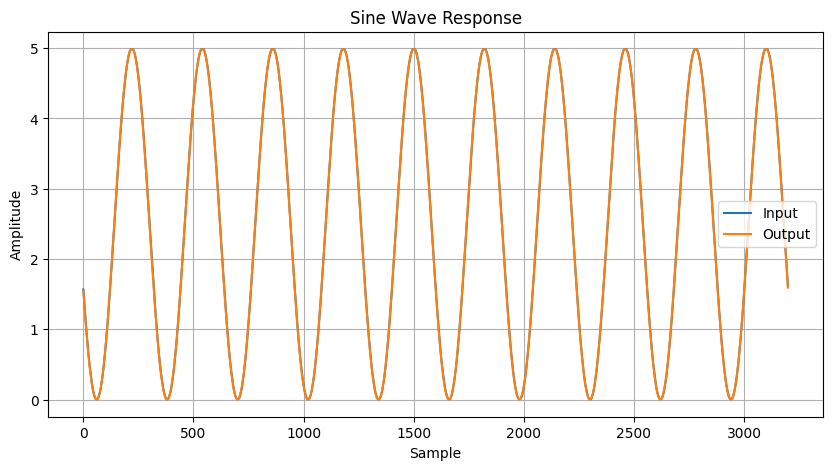

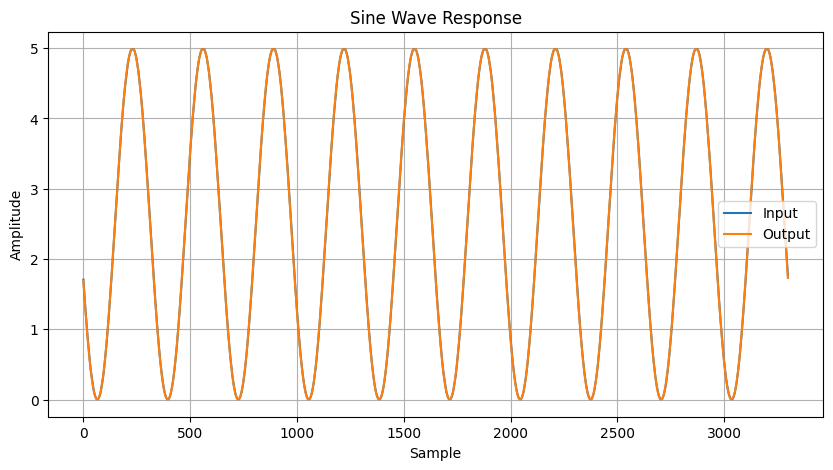

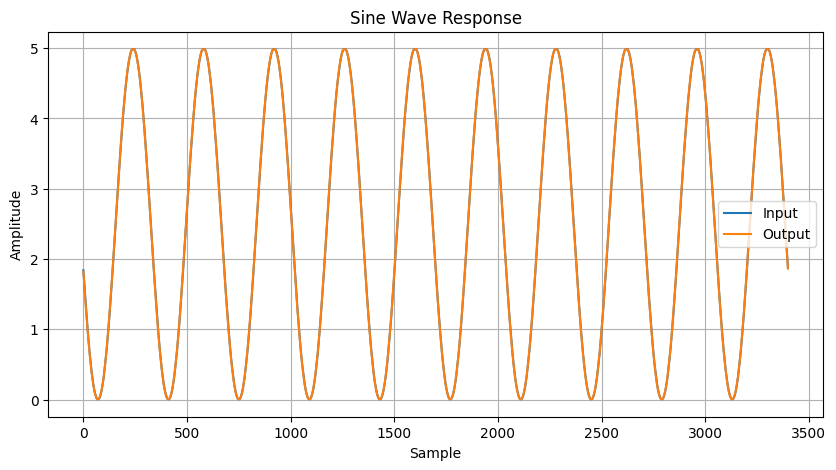

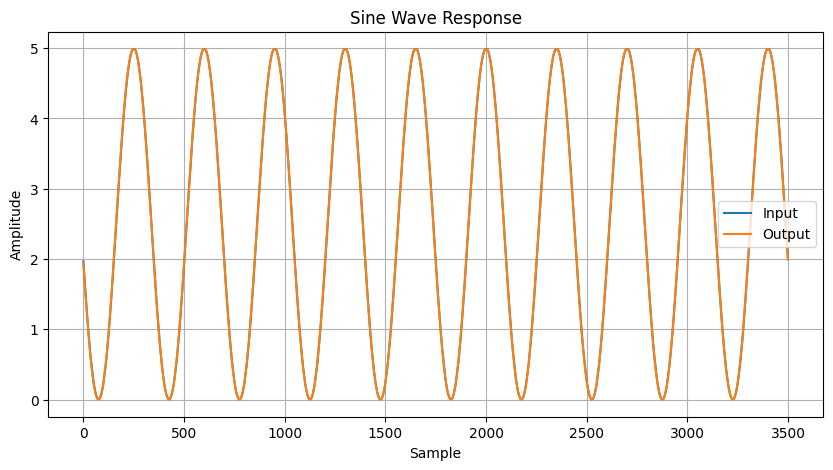

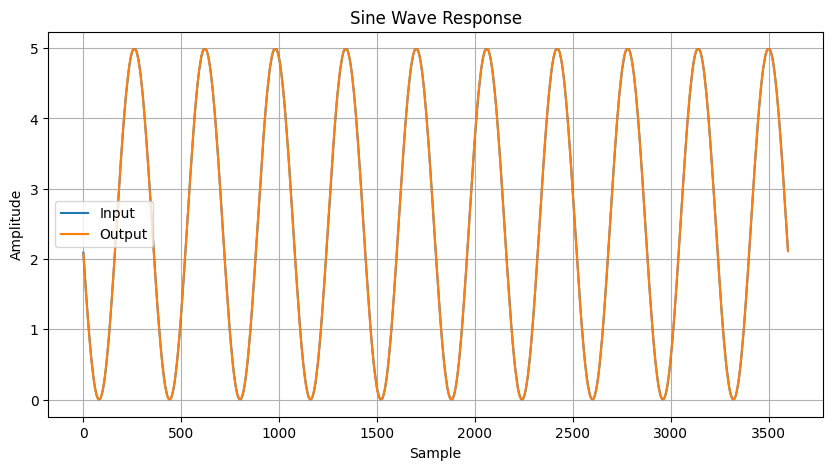

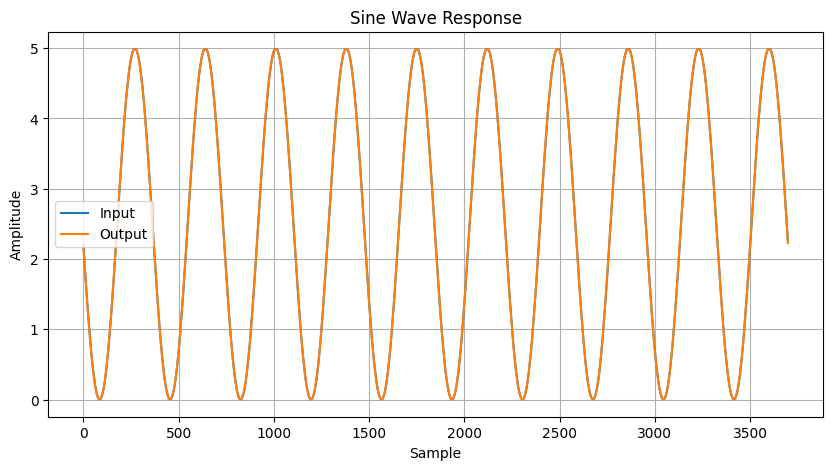

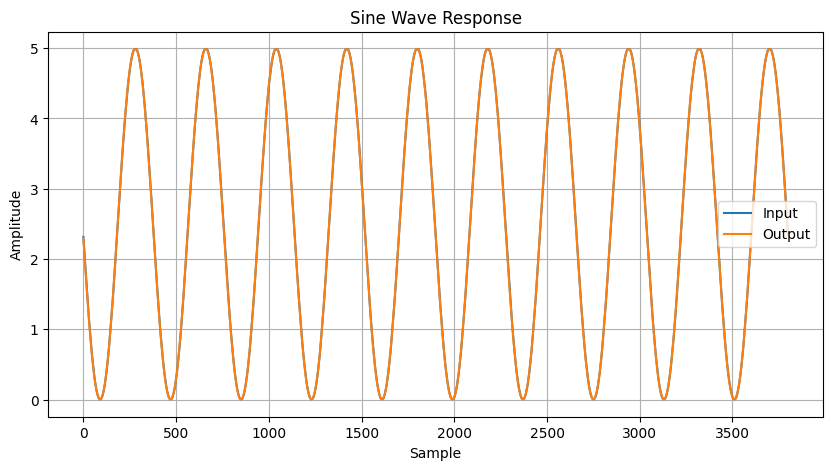

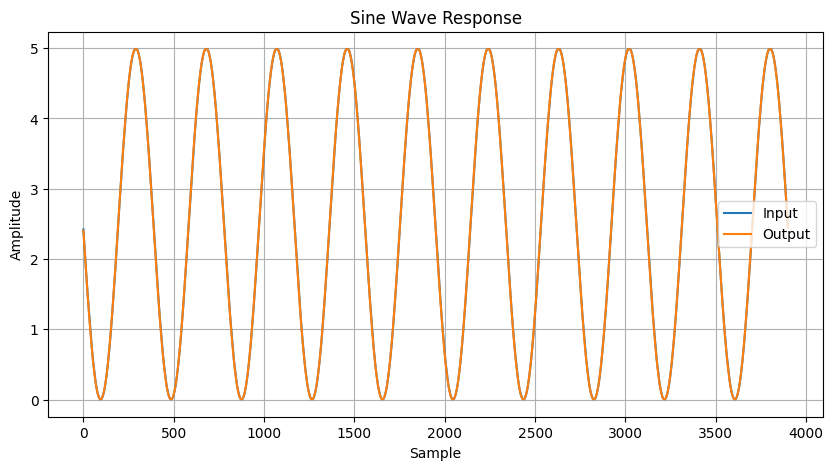

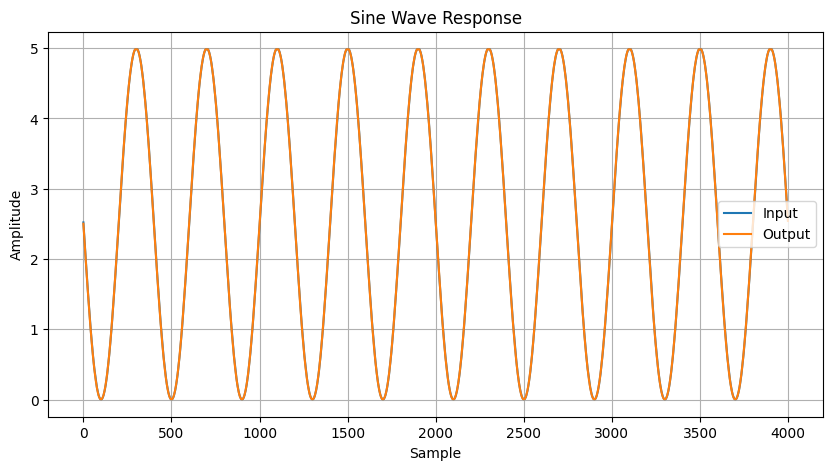

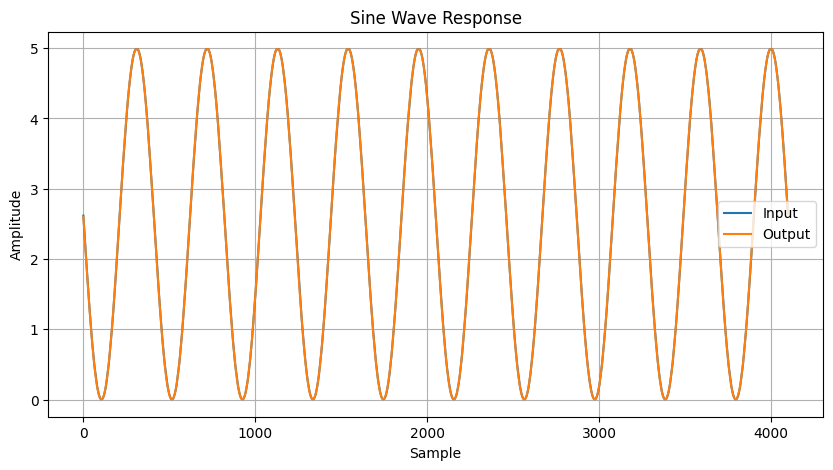

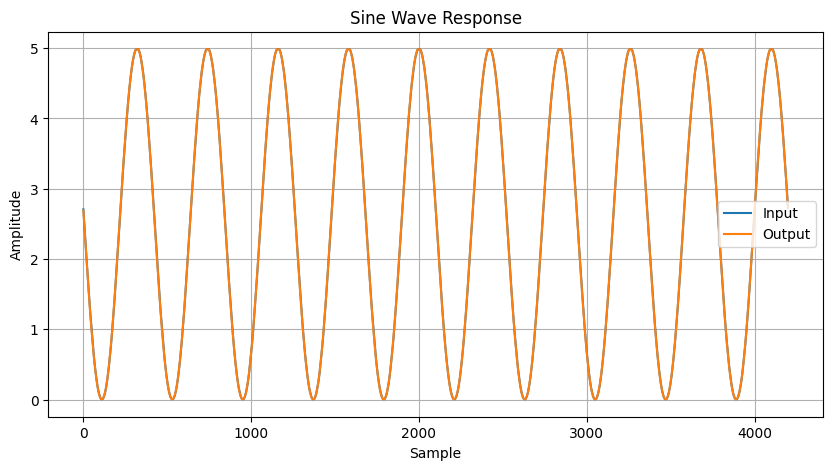

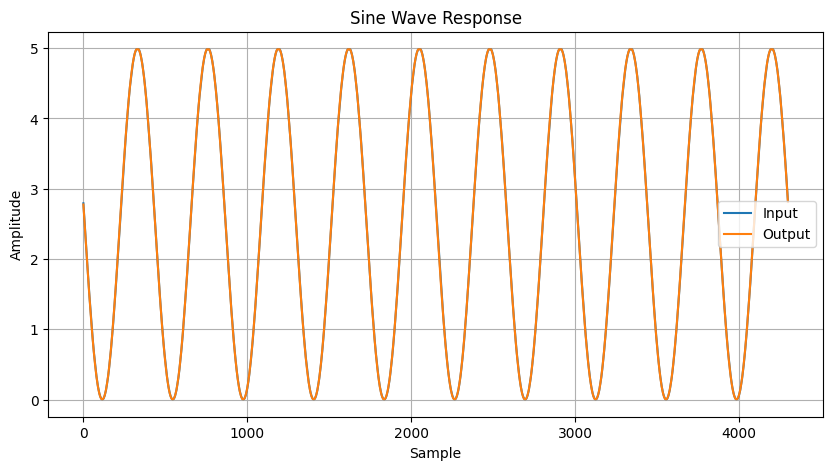

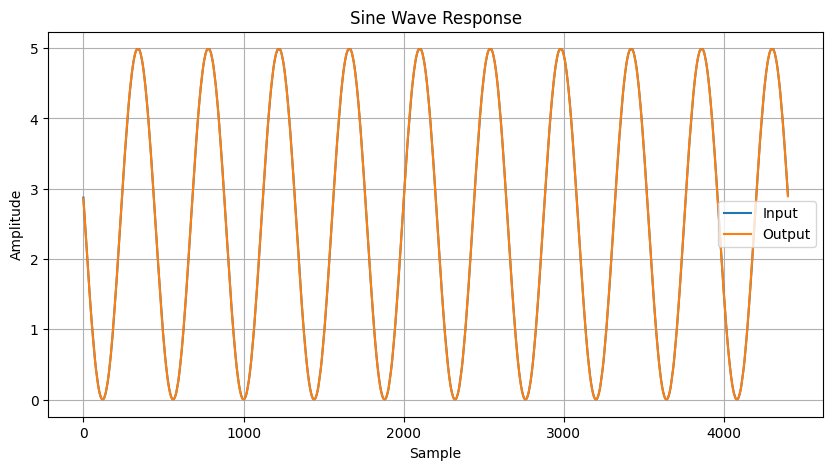

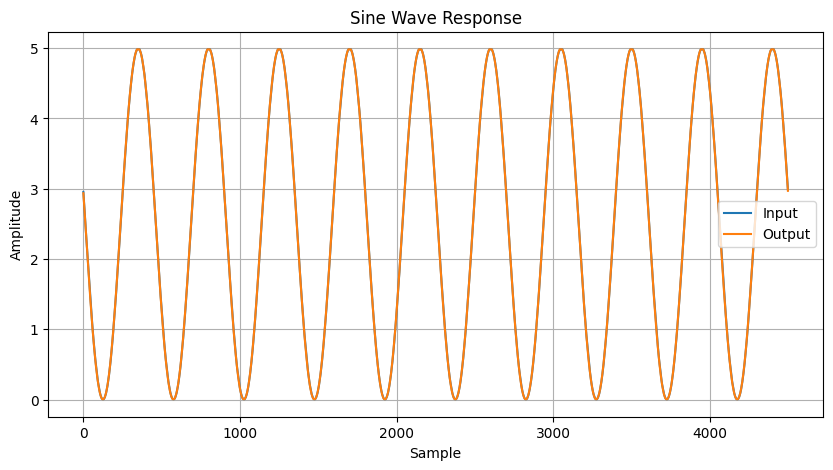

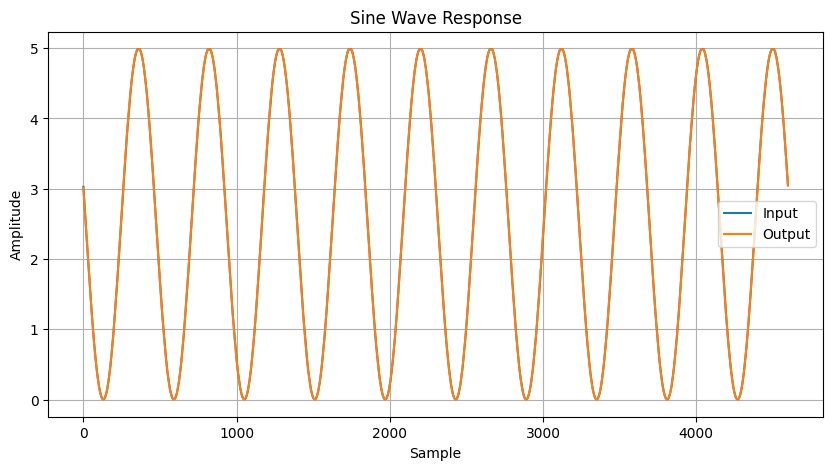

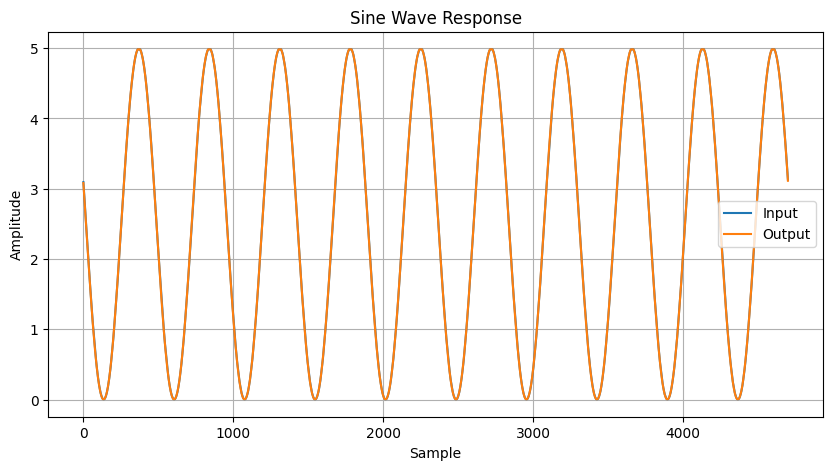

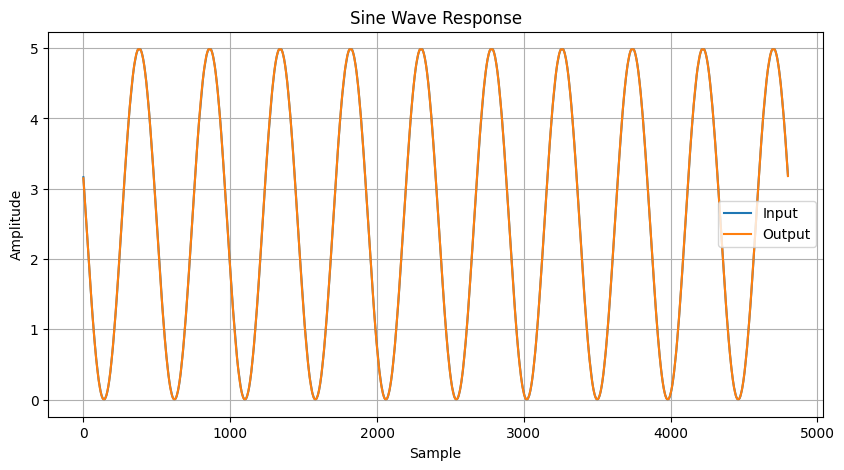

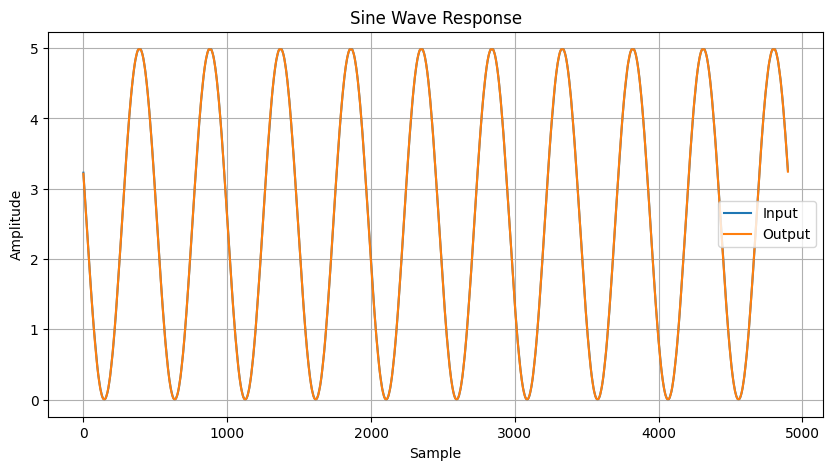

In [14]:
import matplotlib.pyplot as plt
for res in measurement_results:
    inp, out  = res
    plt.figure(figsize=(10, 5))
    plt.plot(inp, label='Input')
    plt.plot(out, label='Output')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.title('Sine Wave Response')
    plt.grid(True)
    plt.legend()
    plt.show()
    

In [33]:
dev.channels["A"].read(10)

[]

In [47]:
import numpy as np
for res,p in zip(measurement_results, ps):
    k=gain_phase(res[0], res[1])
    print(f"Frequency: {k['frequency_cycles_per_sample']:.7f} cycles/sample for set {1/p:.7f} Phase: {k['phase_deg']:.4f} degrees")

Frequency: 0.0500000 cycles/sample for set 0.0500000 Phase: 0.0229 degrees
Frequency: 0.0333333 cycles/sample for set 0.0333333 Phase: -0.0282 degrees
Frequency: 0.0250000 cycles/sample for set 0.0250000 Phase: -0.0343 degrees
Frequency: 0.0200000 cycles/sample for set 0.0200000 Phase: -0.0108 degrees
Frequency: 0.0166667 cycles/sample for set 0.0166667 Phase: -0.0070 degrees
Frequency: 0.0142857 cycles/sample for set 0.0142857 Phase: 0.0179 degrees
Frequency: 0.0125000 cycles/sample for set 0.0125000 Phase: 0.0010 degrees
Frequency: 0.0111111 cycles/sample for set 0.0111111 Phase: 0.0004 degrees
Frequency: 0.0100000 cycles/sample for set 0.0100000 Phase: -0.0044 degrees
Frequency: 0.0090909 cycles/sample for set 0.0090909 Phase: 0.0095 degrees
Frequency: 0.0083333 cycles/sample for set 0.0083333 Phase: 0.0033 degrees
Frequency: 0.0076923 cycles/sample for set 0.0076923 Phase: 0.0111 degrees
Frequency: 0.0071429 cycles/sample for set 0.0071429 Phase: 0.0138 degrees
Frequency: 0.0066667

In [46]:
def gain_phase(inp, out):
    x = np.asarray(inp, dtype=float)
    y = np.asarray(out, dtype=float)

    # Remove DC
    x = x - np.mean(x)
    y = y - np.mean(y)

    N = len(x)

    # FFT
    X = np.fft.rfft(x)
    Y = np.fft.rfft(y)

    # Ignore DC bin
    k = np.argmax(np.abs(X[1:])) + 1

    # Transfer function
    H = Y[k] / X[k]

    mag_linear = np.abs(H)
    mag_db = 20 * np.log10(mag_linear)

    # 1. Get raw phase and frequency
    raw_phase_deg = np.angle(H, deg=True)
    freq_cycles_per_sample = k / N

    # 2. Hardware delay compensation (0.42 samples)
    hardware_delay_samples = 0.456
    
    # Calculate how many degrees of phase lag this time delay causes at this specific frequency
    phase_error_deg = freq_cycles_per_sample * hardware_delay_samples * 360.0
    
    # 3. Add the error back to advance the phase and correct the hardware lag
    true_phase_deg = raw_phase_deg - phase_error_deg

    # Optional: Keep phase wrapped strictly between -180 and +180
    true_phase_deg = (true_phase_deg + 180) % 360 - 180

    return {
        "frequency_cycles_per_sample": freq_cycles_per_sample,
        "magnitude_linear": mag_linear,
        "magnitude_db": mag_db,
        "phase_deg": true_phase_deg,
        "raw_phase_deg": raw_phase_deg  # Good to keep around for debugging
    }